<a href="https://colab.research.google.com/github/vishal786-commits/machine-learning-journey/blob/main/classical-ml/knn-first-principles.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Author: Vishal Gopalkrishna**

# **KNN (k-Nearest Neighbors)**

---

# **What is KNN?**

**K-Nearest Neighbors (KNN)** is a supervised learning algorithm that makes predictions for a new data point by looking at the $k$ closest training data points in feature space.

It does not learn an explicit function during training. Instead, it stores the dataset and performs computation at prediction time.

---

## **Problem Setting: Supervised Learning**

We are given a labeled dataset:

$
\mathcal{D} = \{(x_i, y_i)\}_{i=1}^{n}
$

where:

- $x_i \in \mathbb{R}^d$ is a feature vector  
- $y_i$ is the corresponding label or target  
- $n$ is the number of training samples  

**Goal: Learn a function**

$
f : \mathbb{R}^d \rightarrow \mathcal{Y}
$

that predicts $y$ for a new input $x$.

KNN approximates this function locally using nearby training points.

**It assumes:**

$
\text{Similar inputs } \Rightarrow \text{ Similar outputs}
$

# **Intuition**

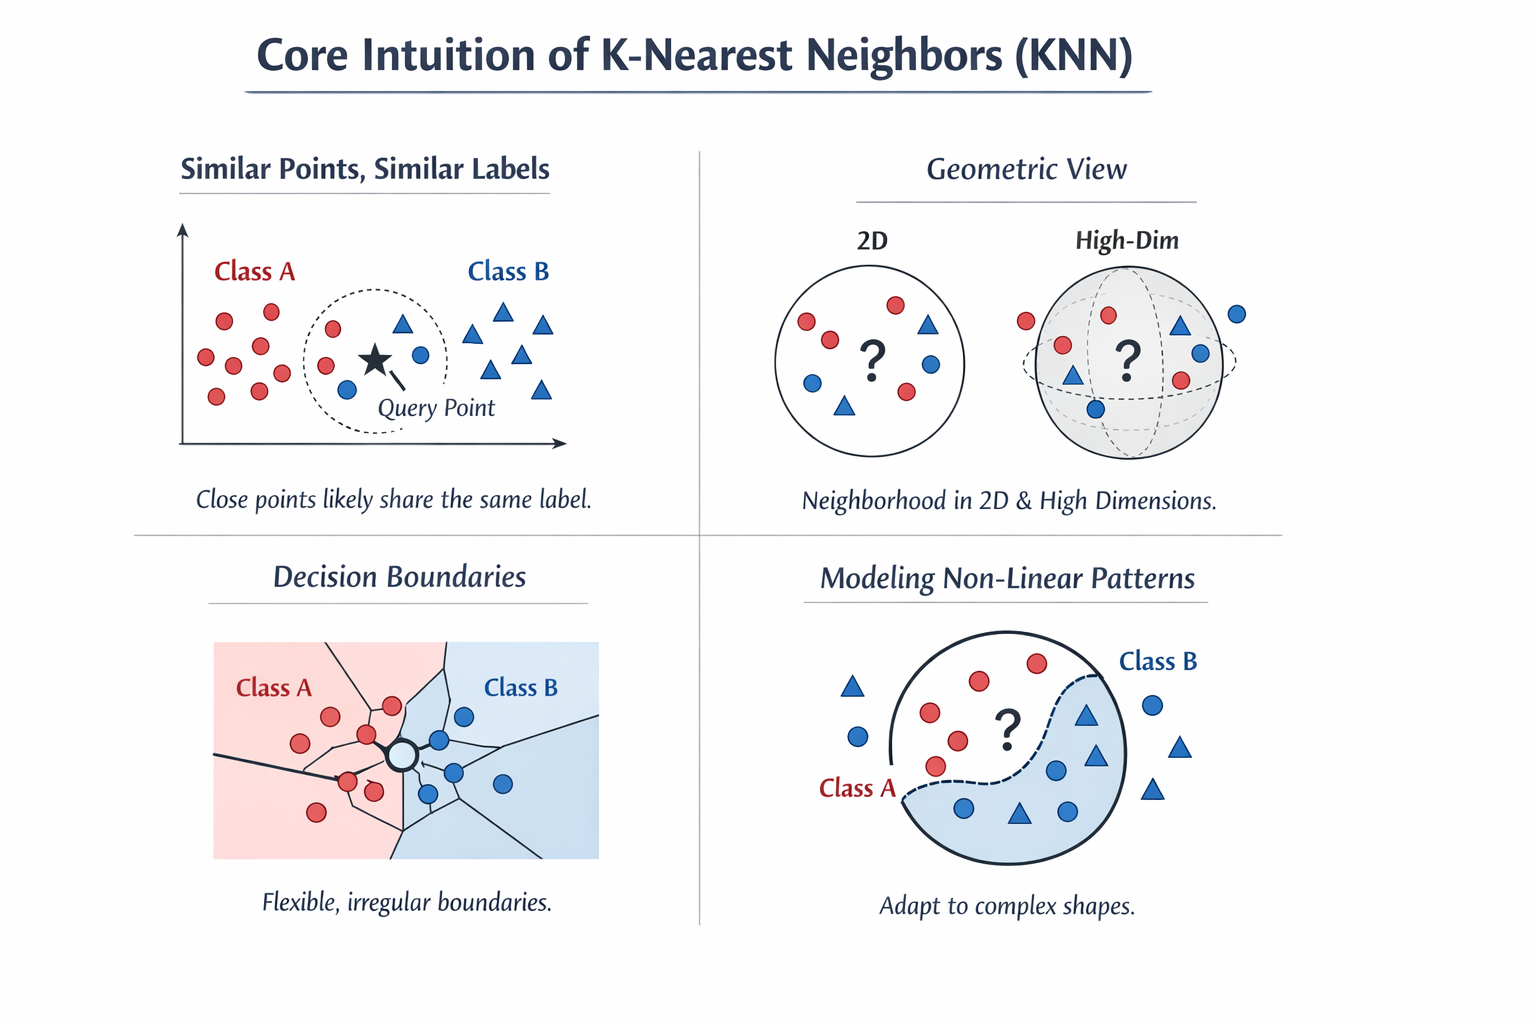




## **Geometric View (2D and High Dimensions)**

Each data point is a vector:

$
x = (x_1, x_2, \dots, x_d) \in \mathbb{R}^d
$

Distance (Euclidean):

$
d(x, x_i) = \sqrt{\sum_{j=1}^{d} (x_j - x_{ij})^2}
$

### In 2D

- Data points lie on a plane.
- A query point forms a circle of radius $r$.
- The $k$ nearest neighbors are the points inside the smallest circle containing $k$ points.

### In Higher Dimensions

- The circle becomes a hypersphere.
- Geometry remains identical:
  
$
\text{Neighborhood} = \{x_i : d(x, x_i) \le r\}
$

KNN does not change structurally in higher dimensions — only distance computation does.

---

## **Decision Boundary Intuition**

The decision boundary is the region where prediction changes class.

For $k = 1$:
- The space is partitioned into regions.
- Each region belongs to the closest training point.
- This forms a Voronoi diagram.

Mathematically:

$
\hat{y}(x) = y_i \quad \text{if} \quad d(x, x_i) < d(x, x_j) \; \forall j \neq i
$

Result:
- Highly irregular boundaries.
- Very flexible.
- Sensitive to noise.

For larger $k$:
- Boundaries become smoother.
- Local noise gets averaged out.

---

## **Why KNN Can Model Non-Linear Patterns**

KNN does not assume:

$
\hat{y} = w^T x + b
$

There is **no global equation**.

Instead, prediction depends only on local neighborhoods.

Example:

Suppose the true boundary is circular:

$
x_1^2 + x_2^2 = r^2
$

A linear model cannot represent this.

But KNN:
- Looks only at nearby points.
- If neighbors inside the circle belong to class A,
- And outside belong to class B,
- KNN naturally learns a circular boundary.

Thus:

$
\text{KNN adapts to local structure instead of fitting a global function.}
$

This makes it a **non-parametric** and **highly flexible** model.




# **Distance Metrics in KNN**

The word **Distance** in this context, defines **what “nearest” means**.  
Choice of metric changes neighborhood shape and model behavior.

---

## **1) Euclidean Distance ($L_2$ Norm)**

$
d(x, z) = \sqrt{\sum_{j=1}^{d} (x_j - z_j)^2}
$

- Straight-line distance.
- Most common.
- Sensitive to scale.

**Example (2D):**

If $x = (1,2)$ and $z = (4,6)$:

$
d = \sqrt{(1-4)^2 + (2-6)^2} = \sqrt{9 + 16} = 5
$

Neighborhood shape → **Circle / Hypersphere**

---

## **2) Manhattan Distance ($L_1$ Norm)**

$
d(x, z) = \sum_{j=1}^{d} |x_j - z_j|
$

- Grid-like movement.
- More robust to outliers than $L_2$.

**Example:**

$
d = |1-4| + |2-6| = 3 + 4 = 7
$

Neighborhood shape → **Diamond / Hypercube**

---

## **3) Minkowski Distance (General Form)**

$
d(x, z) = \left( \sum_{j=1}^{d} |x_j - z_j|^p \right)^{1/p}
$

- $p=1$ → Manhattan  
- $p=2$ → Euclidean  
- $p \to \infty$ → Chebyshev

Controls geometry smoothly.

---

## **4) Chebyshev Distance ($L_\infty$ Norm)**

$
d(x, z) = \max_j |x_j - z_j|
$

- Maximum coordinate difference.
- Used in grid-based problems.

Neighborhood shape → **Square / Hypercube**

---

## **5) Cosine Distance**

First compute cosine similarity:

$
\text{cos}(x,z) = \frac{x \cdot z}{\|x\|\|z\|}
$

Cosine distance:

$
d = 1 - \text{cos}(x,z)
$

- Measures angle, not magnitude.
- Common in text / embeddings.

---

# **Key Insight**

- $L_2$ emphasizes large coordinate differences.
- $L_1$ treats all differences linearly.
- Cosine ignores magnitude.
- Metric choice changes decision boundary geometry.

Distance metric = definition of similarity.